In [1]:
import re
import sys
from pathlib import Path
from typing import Any, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT, load_all_synthetic_variants, pytorch_to_igraph
from src.graph_analysis import calculate_moments_error, calculate_annd_error, calculate_eccentricity_error
from notebooks.visualization_utils import plot_performance_distribution, set_dynamic_ylim

In [2]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
METHODS = ["padma", "anndg", "anndgE", "nextGen"]
IGNORED_METRICS = ["diameter"]
PALETTE = {
    "nextGen": "#5B9BD5", 
    "dummyNodes": "#DA7CF7",
    "dummyEdges": "#98C379", 
    "padma": "#F5C431", 
    "anndg": "#E06C75",
    "anndgD": "#5CE9FF", 
    "anndgE": "#C47900",
    "anndgED": "#5242D1", 
    }

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []
    original_stats_map = {}

    def extract_errors(stats):
        """Extracts stats as numpy arrays for error calculation."""
        deg_moments = np.array(stats.get("normalized_degree_moments", [0]*4))
        annd = np.array(stats.get("annd", [0]*4))
        eccentricity = np.array(stats.get("eccentricity", [0]*4))
        return deg_moments, annd, eccentricity

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])
            for i, stats in enumerate(per_graph_stats):
                deg_moments, annd, eccentricity = extract_errors(stats)
                original_stats_map[(dataset_name, i)] = {
                    "deg_moments": deg_moments,
                    "annd": annd,
                    "eccentricity": eccentricity,
                }
                
                row = {
                    "dataset": dataset_name,
                    "method": "original",
                    "graph_idx": i,
                    "variant_idx": -1,
                    "seed": pd.NA,
                    "deg_moments_error": 0.0,
                    "annd_error": 0.0,
                    "eccentricity_error": 0.0,
                }
                # Flatten the stats dictionary
                for key, value in stats.items():
                    if isinstance(value, (list, np.ndarray)):
                        for idx, val in enumerate(value):
                            row[f"{key}_{idx}"] = val
                    else:
                        row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
            
        # Load synthetic variants
        for method in METHODS:
            method_dir = PROJECT_ROOT / "synthetic_data" / dataset_name / method
            if not method_dir.exists():
                continue
            
            variant_paths = load_all_synthetic_variants(method_dir, dataset_name)
            for v_idx, v_path in enumerate(variant_paths):
                dataset_obj = DatasetPT(v_path)
                per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])
                seeds = dataset_obj.metadata.get("seeds", [])
                for i, stats in enumerate(per_graph_stats):
                    # Get target stats
                    orig = original_stats_map.get((dataset_name, i))
                    if orig:
                        deg_moments, annd, eccentricity = extract_errors(stats)
                        
                        dm_err = calculate_moments_error(deg_moments, orig["deg_moments"])
                        annd_err = calculate_annd_error(annd, orig["annd"])
                        ecc_err = calculate_eccentricity_error(eccentricity, orig["eccentricity"])
                    else:
                        dm_err = annd_err = ecc_err = np.nan

                    row = {
                        "dataset": dataset_name,
                        "method": method,
                        "graph_idx": i,
                        "variant_idx": v_idx,
                        "deg_moments_error": dm_err,
                        "annd_error": annd_err,
                        "eccentricity_error": ecc_err,
                        "seed": seeds[i] if i < len(seeds) else pd.NA,
                    }
                    # Flatten the stats dictionary
                    for key, value in stats.items():
                        if isinstance(value, (list, np.ndarray)):
                            for idx, val in enumerate(value):
                                row[f"{key}_{idx}"] = val
                        else:
                            row[key] = value
                    rows.append(row)
            
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

def compute_generation_errors(df: pd.DataFrame) -> pd.DataFrame:
    """Calculates absolute deltas for all statistics between synthetic and original graphs.
    
    Returns a DataFrame where each row is a synthetic graph variant and columns 
    contain the absolute difference |orig - synth| for each metric.
    """
    # 1. Separate original and synthetic data
    df_orig = df[df["method"] == "original"].set_index(["dataset", "graph_idx"])
    df_synth = df[df["method"] != "original"].copy()
    
    # 2. Identify columns to compute deltas for (all stats columns)
    metadata_cols = ["dataset", "method", "graph_idx", "variant_idx", "seed",
                     "deg_moments_error", "annd_error", "eccentricity_error"]
    stat_cols = [c for c in df.columns if c not in metadata_cols and c not in IGNORED_METRICS]
    
    # 3. Vectorized delta calculation for each statistic
    error_rows = []
    # Grouping by dataset and graph_idx to match variants to their originals
    for (dataset, g_idx), group in df_synth.groupby(["dataset", "graph_idx"], observed=True):
        if (dataset, g_idx) not in df_orig.index:
            continue
        orig_row = df_orig.loc[(dataset, g_idx)]
        
        for _, synth_row in group.iterrows():
            err_row = {
                "dataset": dataset,
                "method": synth_row["method"],
                "graph_idx": g_idx,
                "variant_idx": synth_row["variant_idx"],
                "seed": synth_row.get("seed", np.nan),
                "deg_moments_error": synth_row["deg_moments_error"],
                "annd_error": synth_row["annd_error"],
                "eccentricity_error": synth_row["eccentricity_error"]
            }
            # Compute absolute delta for each topological statistic
            for col in stat_cols:
                if col in synth_row and col in orig_row:
                    err_row[col] = abs(synth_row[col] - orig_row[col])
            error_rows.append(err_row)
            
    df_errs = pd.DataFrame(error_rows)
    if "seed" in df_errs.columns:
        df_errs["seed"] = df_errs["seed"].astype("Int64")
    return df_errs

# Load data and compute errors
df = load_generation_data()
df_errors = compute_generation_errors(df)

# Global config variables used in analysis
filtered_src = df[df["method"] != "original"].sort_values("method")
METHODS_PER_DATASET = filtered_src.groupby("dataset", observed=True)["method"].unique().apply(list).to_dict()
DATASETS = [d for d in DATASET_NAMES if d in df["dataset"].unique()]

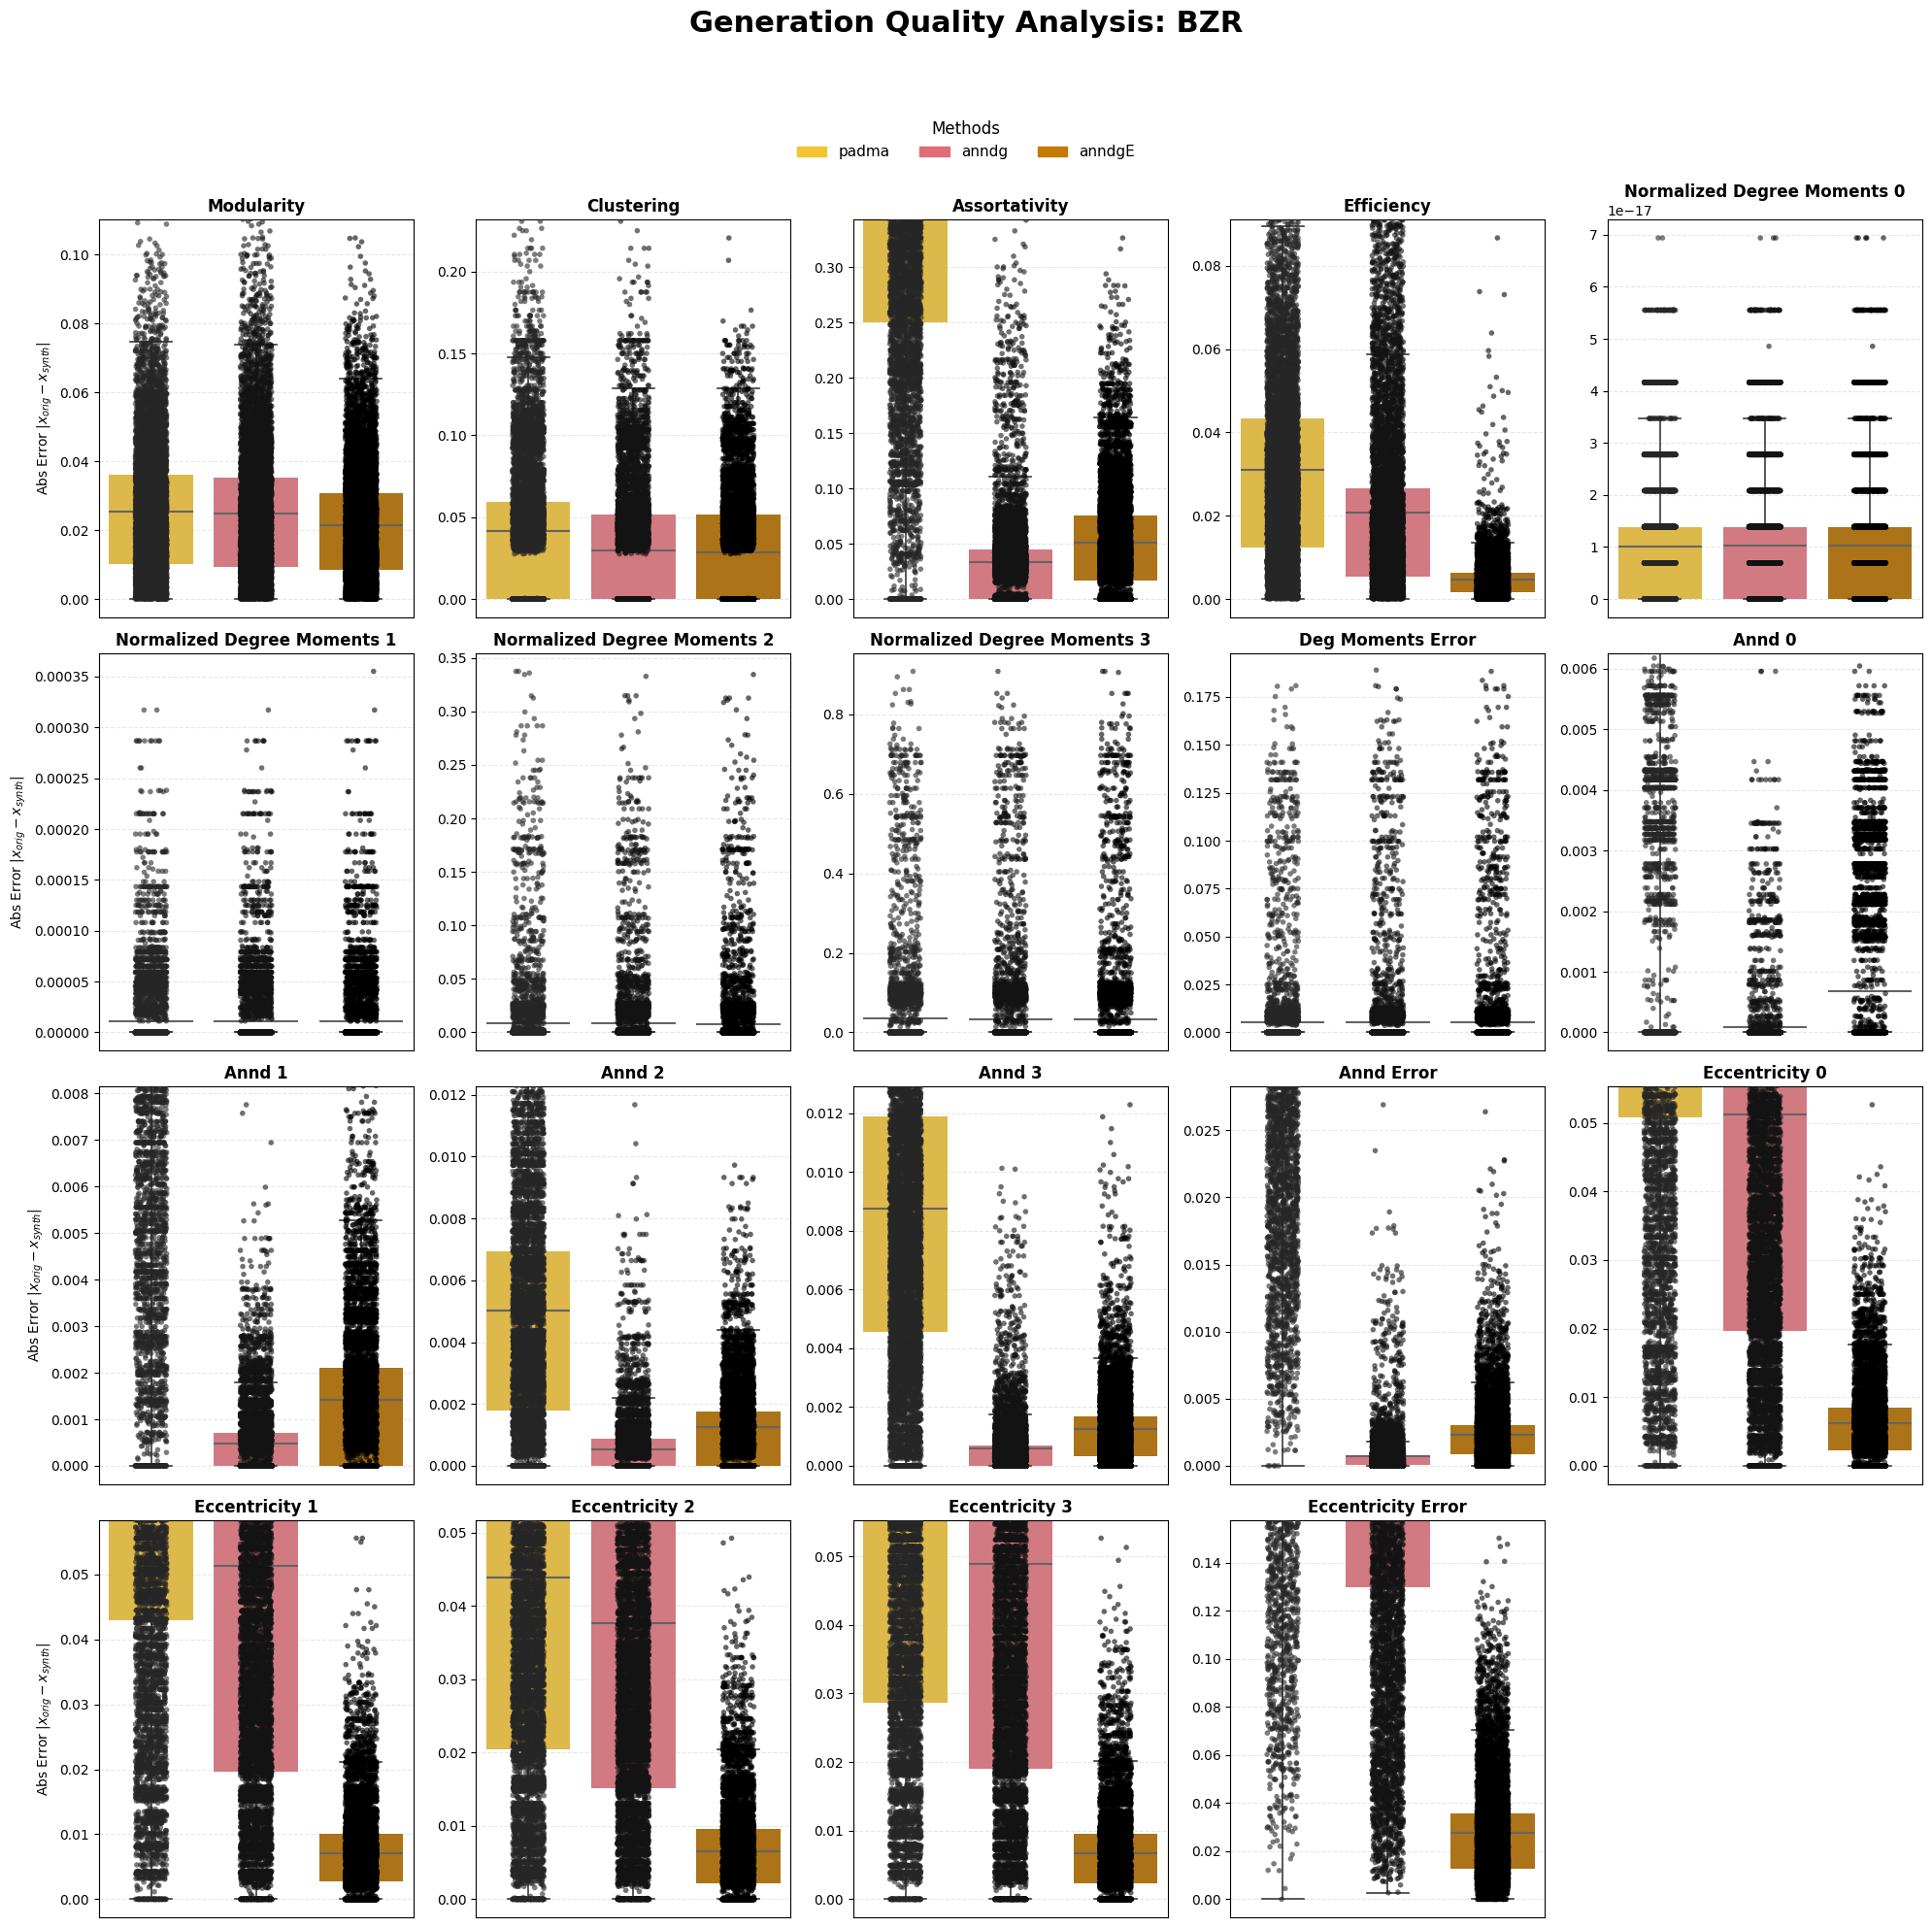


--- Top 5 errors for metric 'assortativity' (Dataset: BZR, Method: anndg) ---


,dataset,method,graph_idx,variant_idx,seed,assortativity,annd_0,annd_1,annd_2,annd_3,annd_error
3020,BZR,anndg,50,0,1521050759,0.387755,0.003352,0.002535,0.008089,0.014292,0.026905
9081,BZR,anndg,151,1,463836215,0.365383,0.000772,0.000987,0.008122,0.010124,0.017724
21807,BZR,anndg,363,7,2146679184,0.346193,0.000526,0.002258,0.003670,0.003689,0.005635
13105,BZR,anndg,218,5,1656327797,0.342439,0.002674,0.000479,0.001510,0.002219,0.003113
9144,BZR,anndg,152,4,1540482986,0.332799,0.000526,0.002841,0.002861,0.004153,0.005818


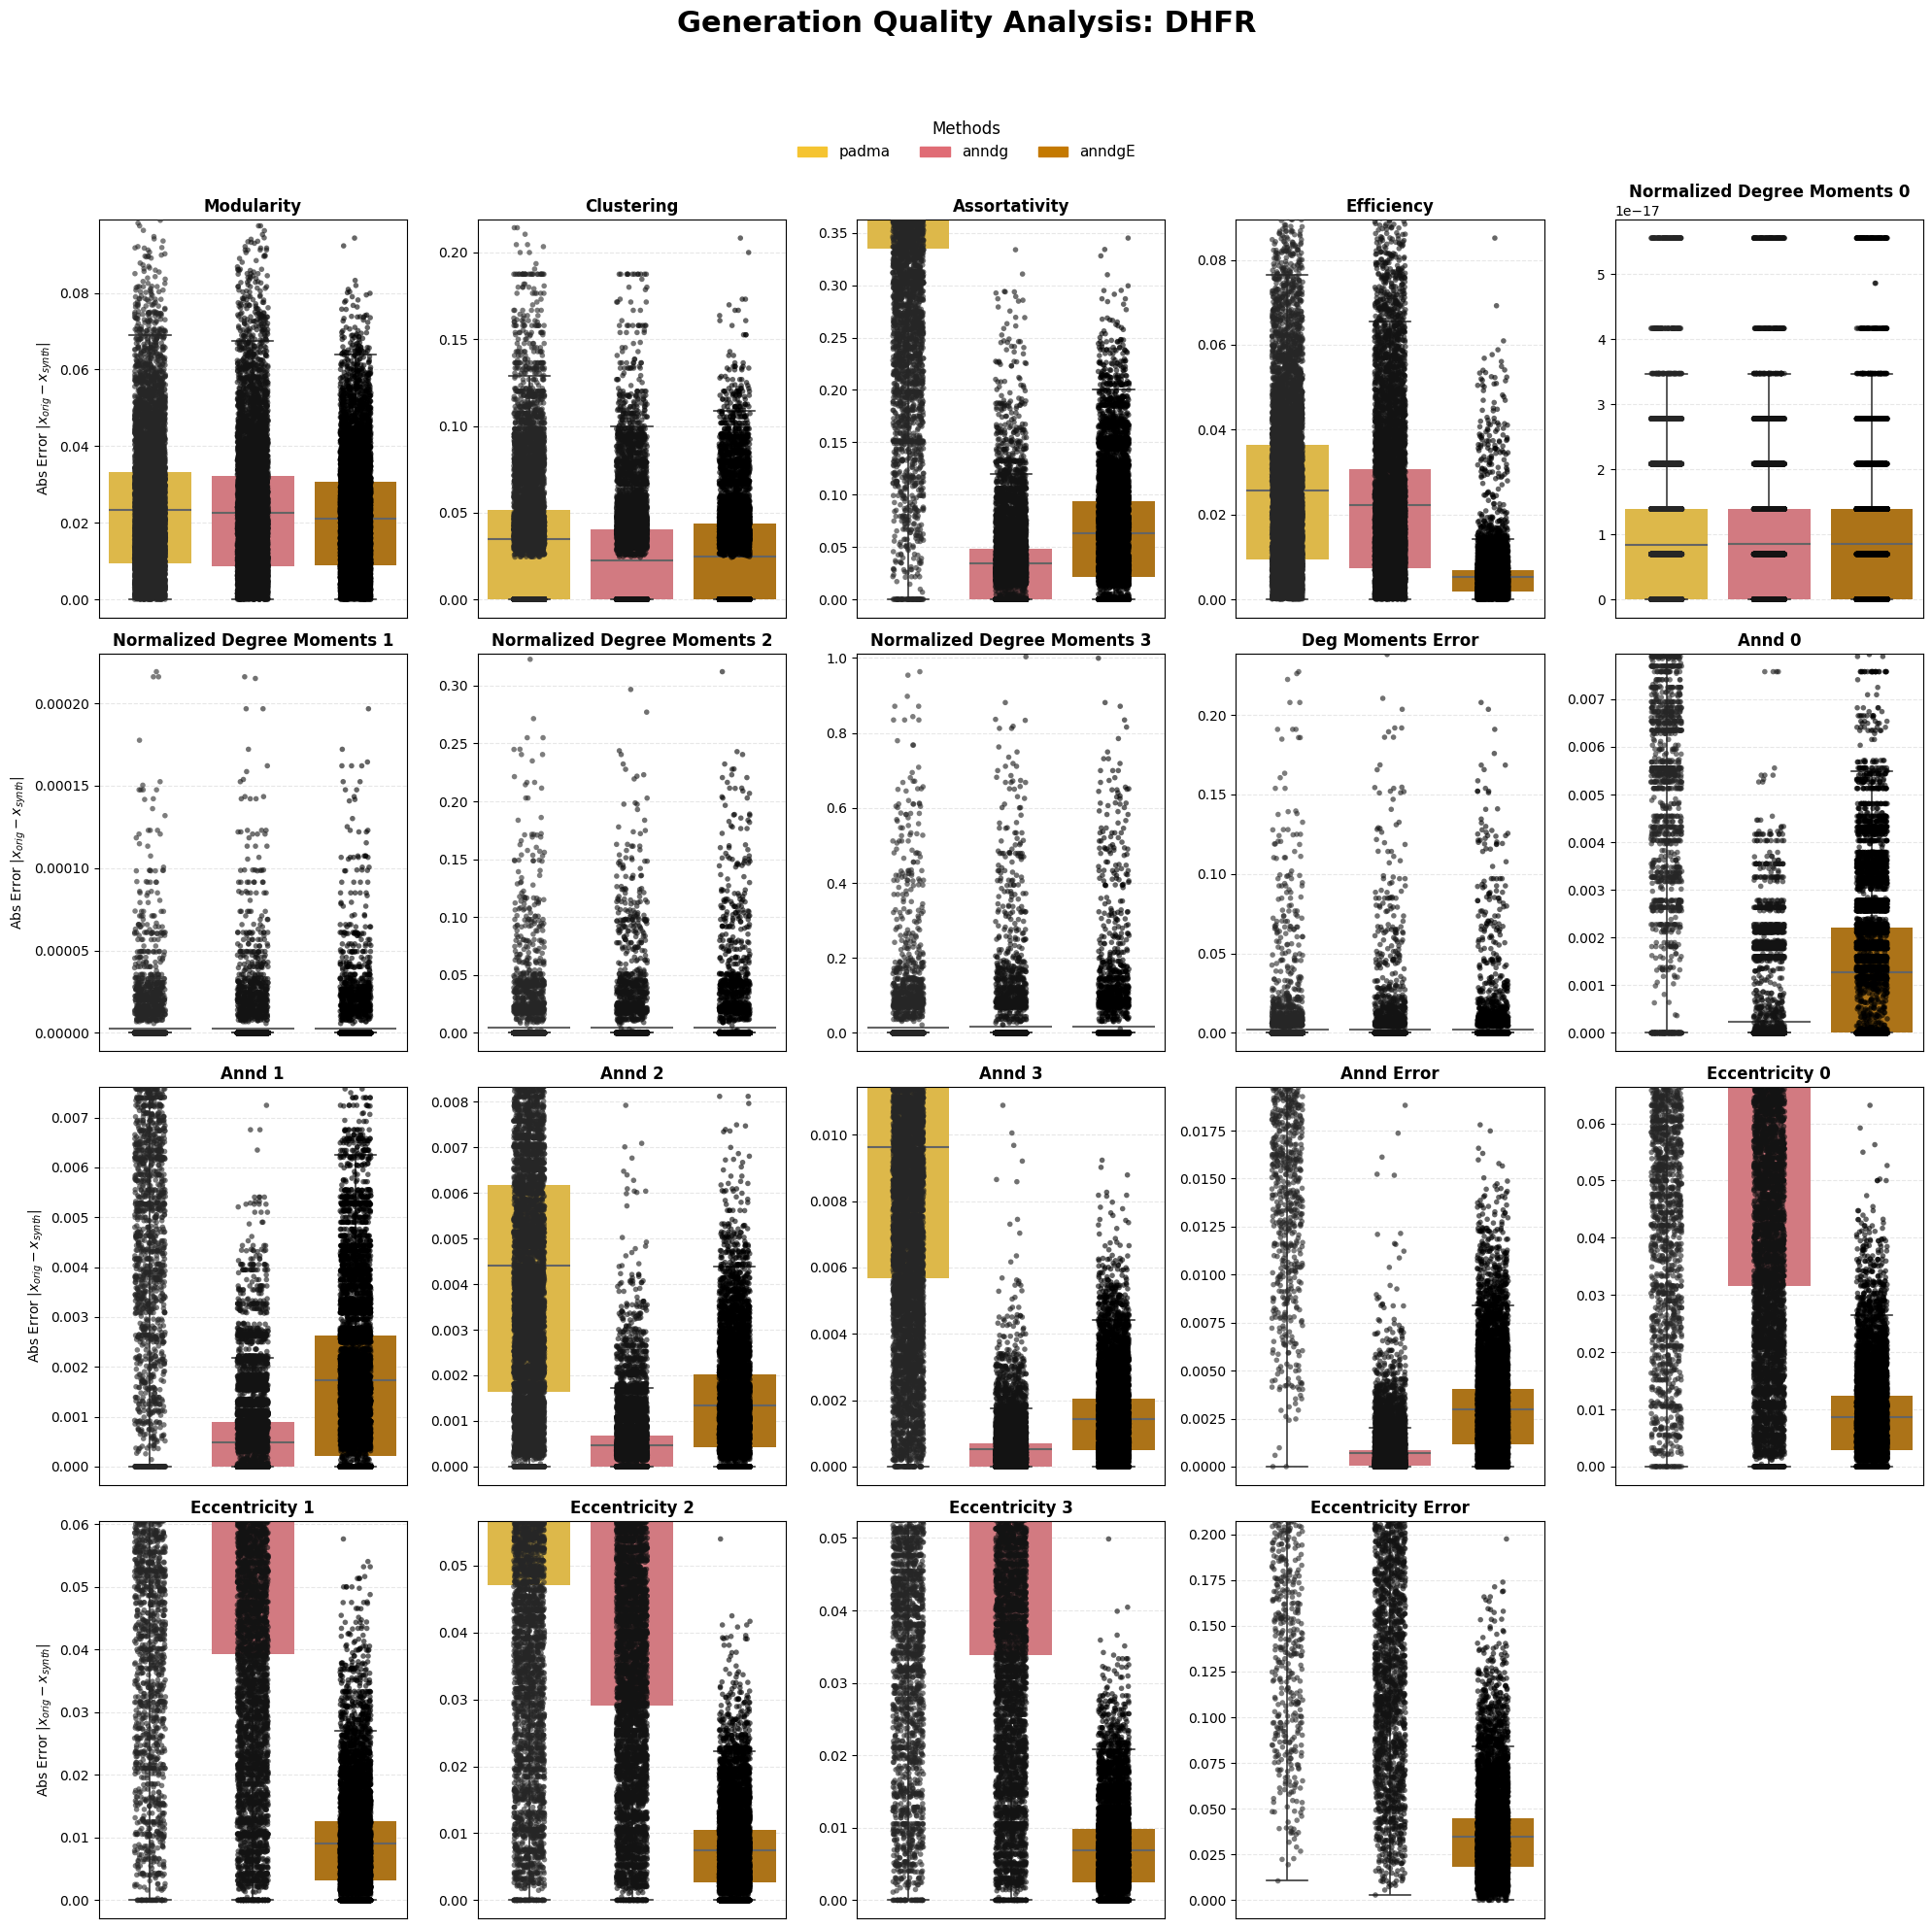


--- Top 5 errors for metric 'assortativity' (Dataset: DHFR, Method: anndg) ---


,dataset,method,graph_idx,variant_idx,seed,assortativity,annd_0,annd_1,annd_2,annd_3,annd_error
24207,DHFR,anndg,3,7,1101944861,0.379613,0.000687,0.000711,0.007084,0.010883,0.017365
24215,DHFR,anndg,3,15,751772893,0.365998,0.000687,0.003211,0.007918,0.010050,0.018818
42990,DHFR,anndg,316,10,1679683165,0.333870,0.000277,0.000026,0.001504,0.001199,0.001045
33813,DHFR,anndg,163,13,978845628,0.310680,0.000631,0.003132,0.006037,0.005297,0.010379
24202,DHFR,anndg,3,2,374955943,0.294026,0.000503,0.000839,0.003524,0.003413,0.004425


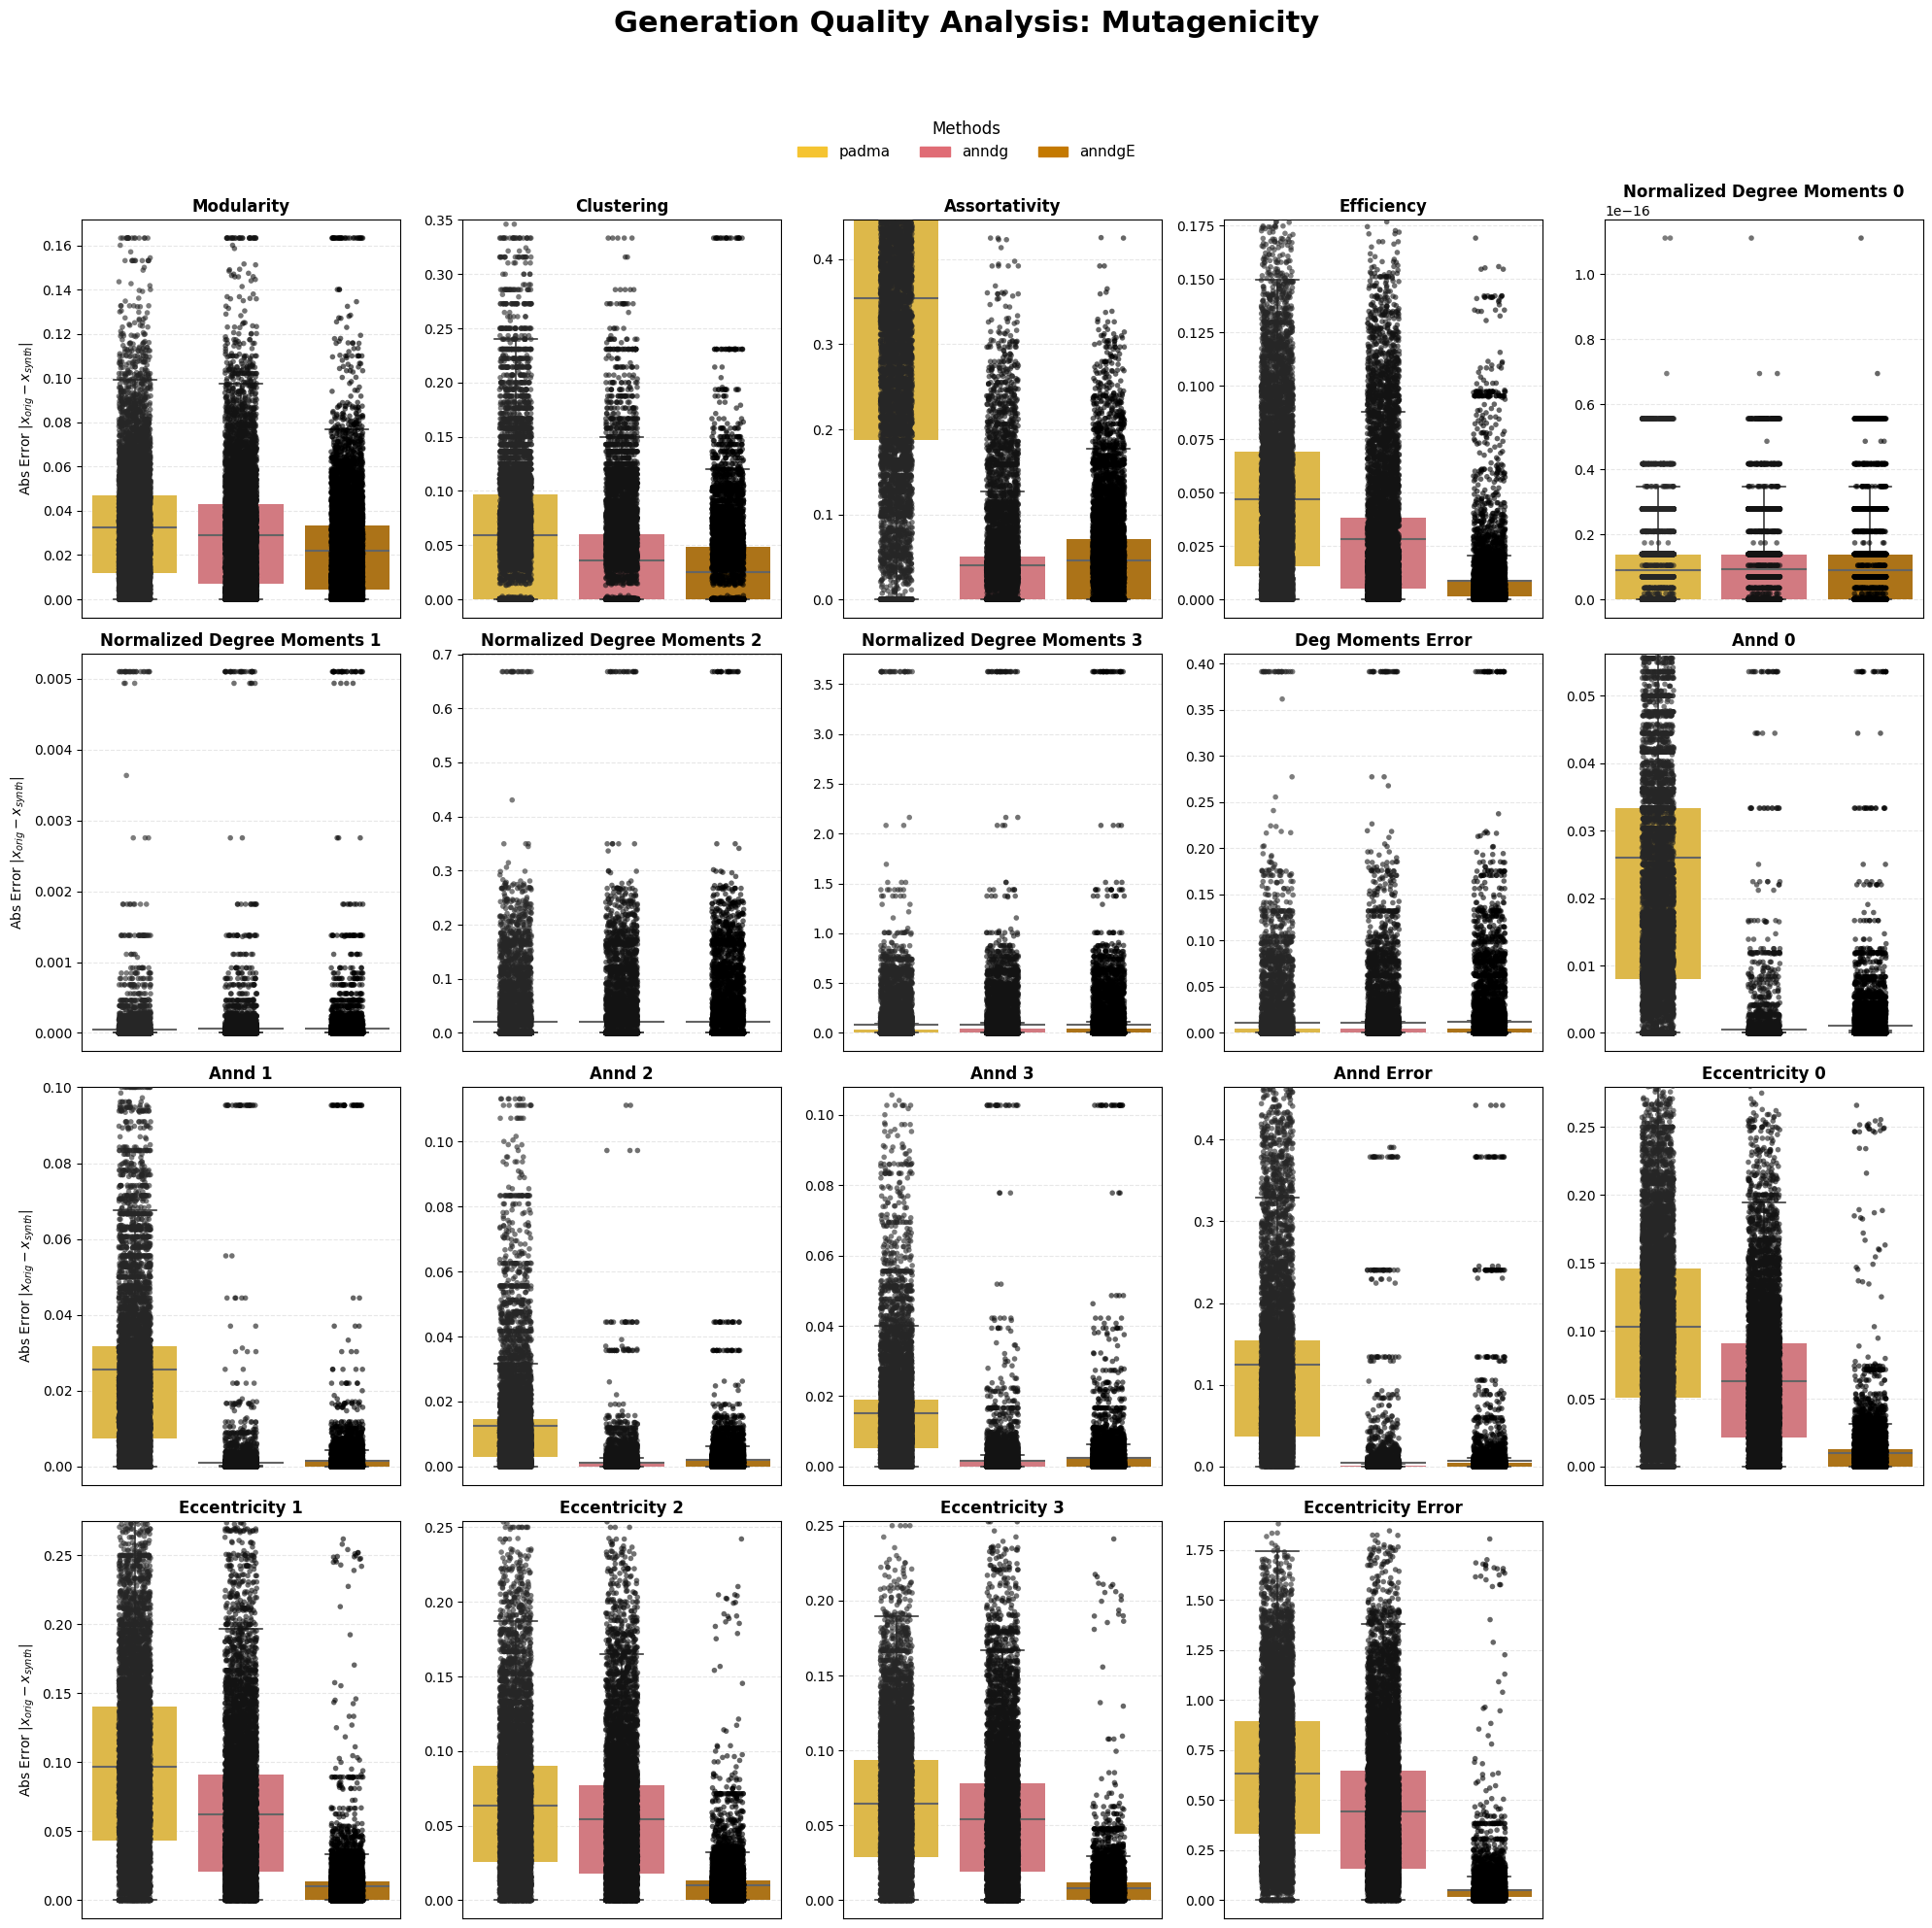


--- Top 5 errors for metric 'assortativity' (Dataset: Mutagenicity, Method: anndg) ---


,dataset,method,graph_idx,variant_idx,seed,assortativity,annd_0,annd_1,annd_2,annd_3,annd_error
73413,Mutagenicity,anndg,235,13,904408882,0.425012,0.016667,0.000000,0.013889,0.026007,0.075268
77969,Mutagenicity,anndg,311,9,35126616,0.425012,0.000000,0.000000,0.008333,0.032118,0.059296
68964,Mutagenicity,anndg,161,4,1903610679,0.423091,0.021164,0.055556,0.111111,0.157143,0.674148
68969,Mutagenicity,anndg,161,9,234063238,0.423091,0.021164,0.055556,0.111111,0.157143,0.674148
68725,Mutagenicity,anndg,157,5,897056509,0.413706,0.000126,0.003206,0.004013,0.007950,0.011341


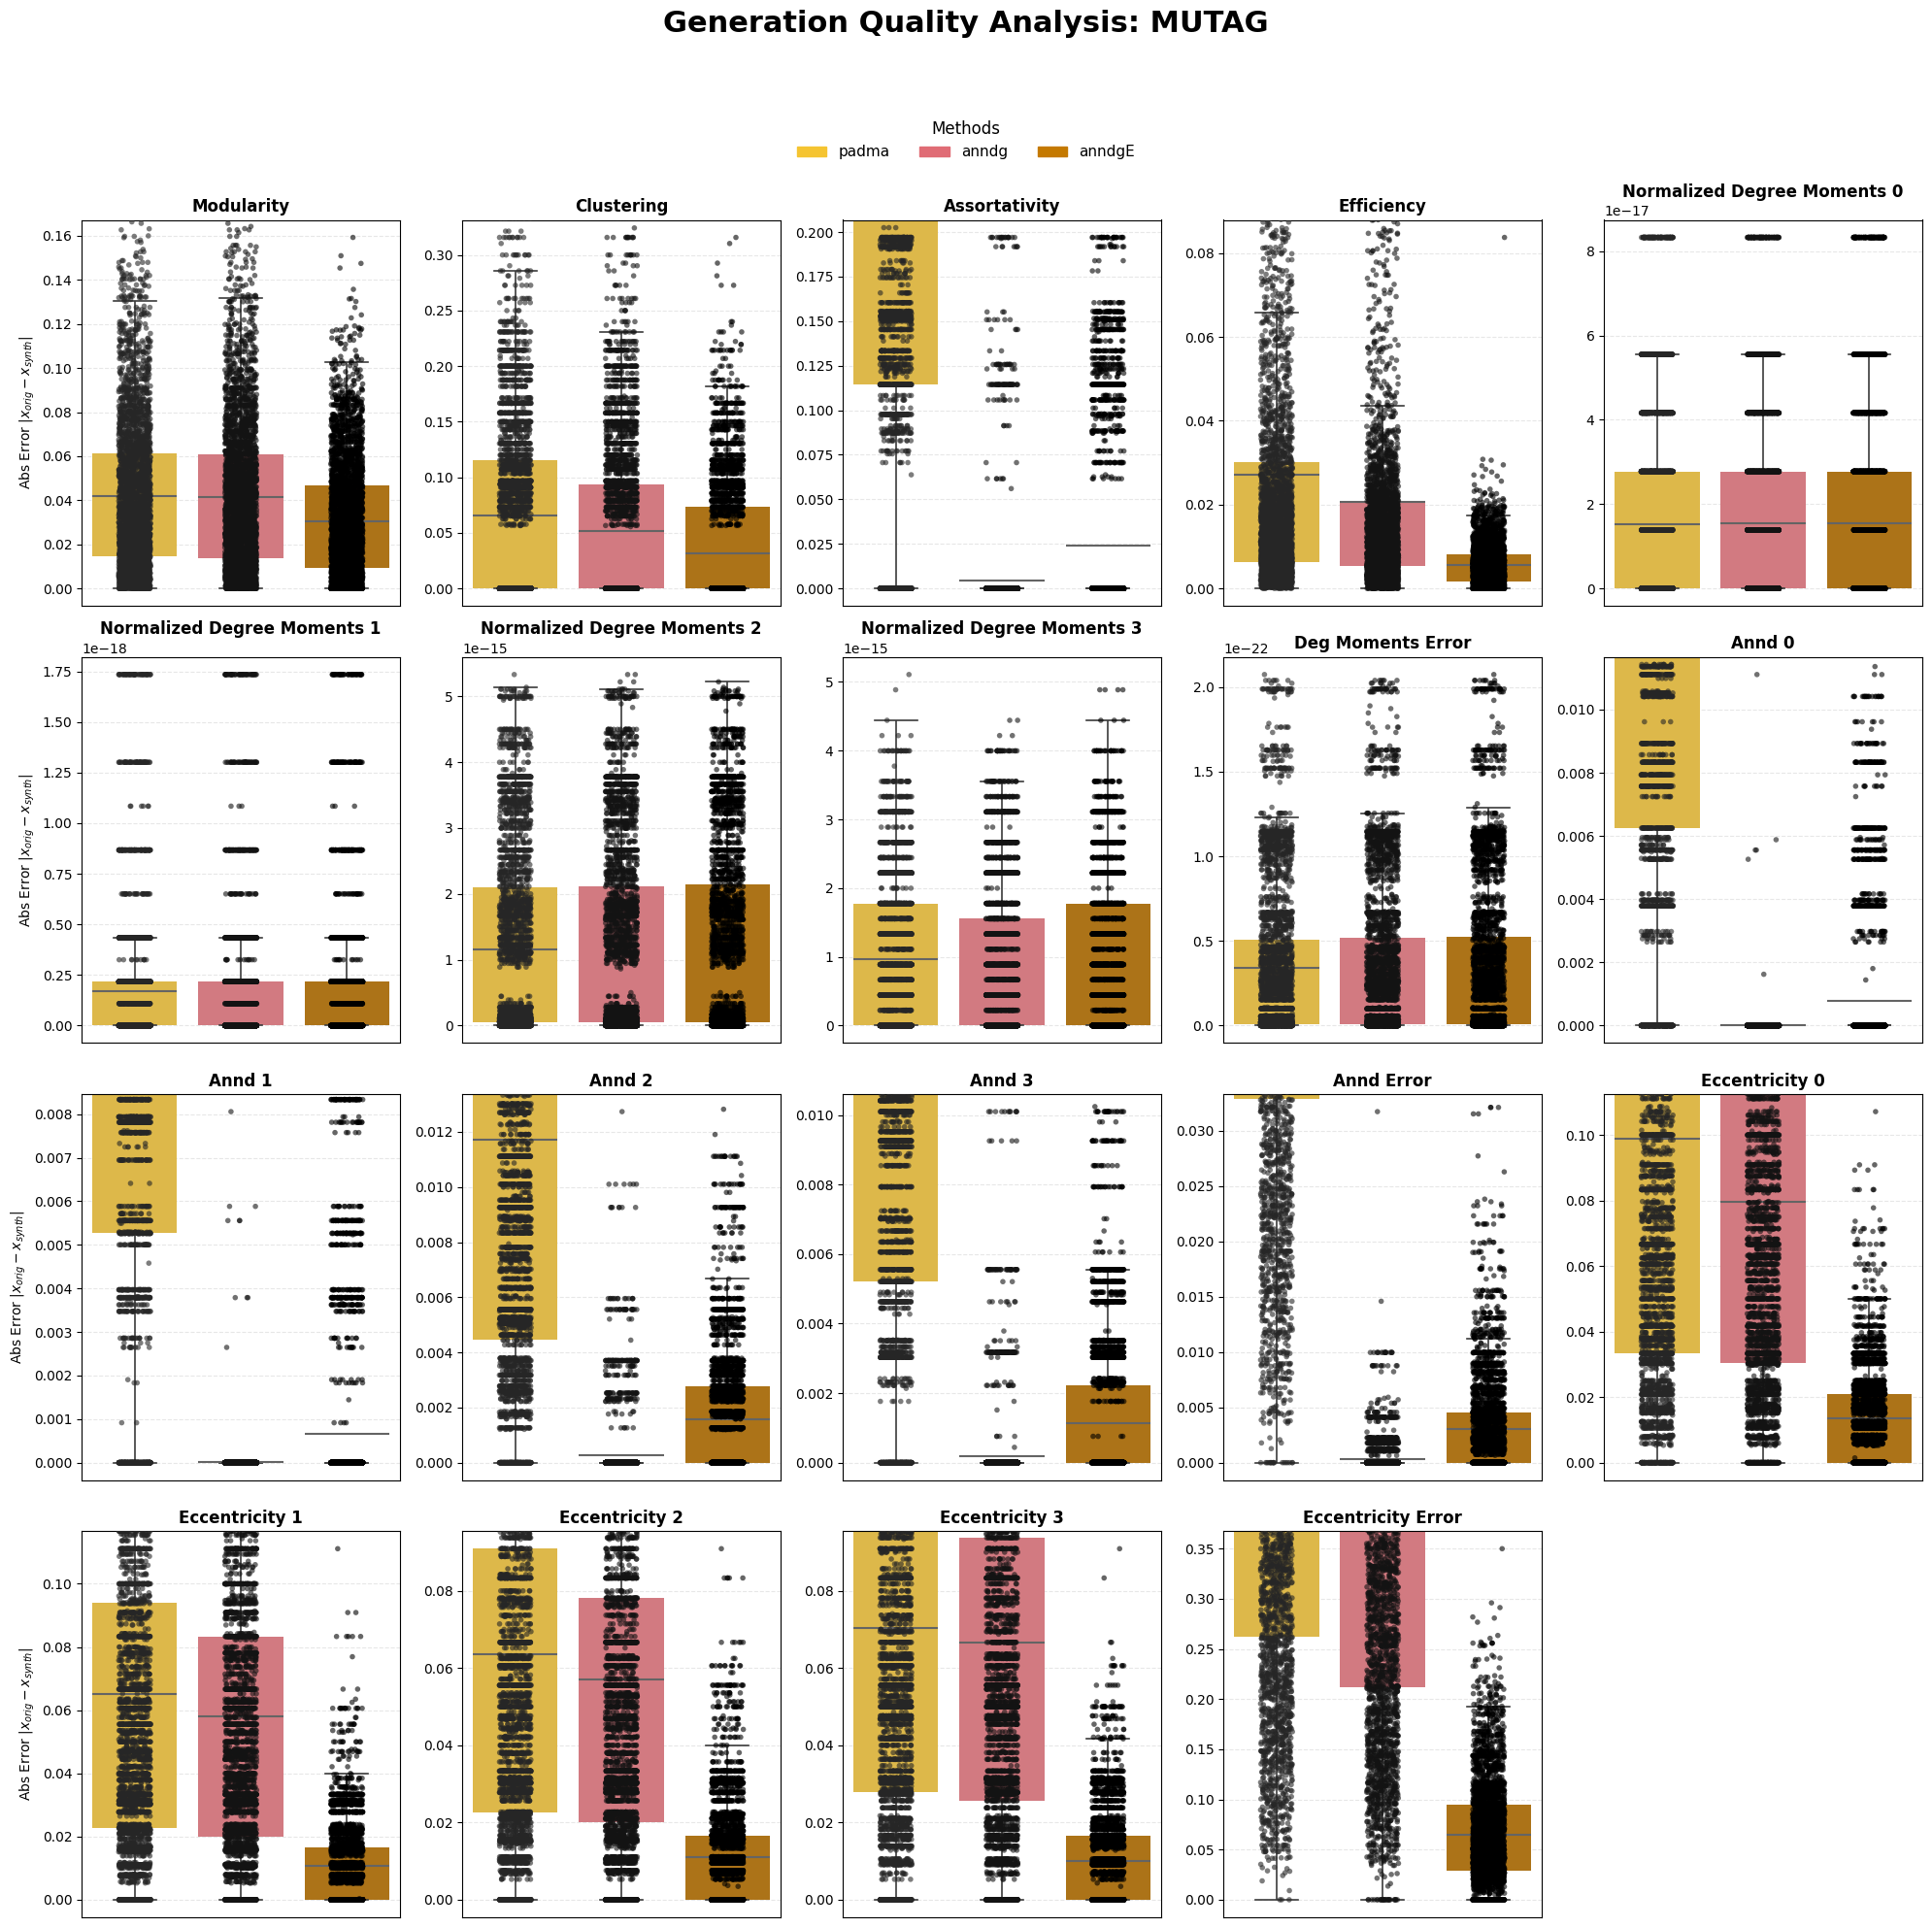


--- Top 5 errors for metric 'assortativity' (Dataset: MUTAG, Method: anndg) ---


,dataset,method,graph_idx,variant_idx,seed,assortativity,annd_0,annd_1,annd_2,annd_3,annd_error
57214,MUTAG,anndg,153,14,2098359393,0.19697,0.0,0.0,1.010101e-02,0.000000,0.009951
57212,MUTAG,anndg,153,12,1053691589,0.19697,0.0,0.0,5.551115e-17,0.010101,0.009951
57210,MUTAG,anndg,153,10,1326575263,0.19697,0.0,0.0,5.551115e-17,0.010101,0.009951
58539,MUTAG,anndg,175,19,2106602163,0.19697,0.0,0.0,1.010101e-02,0.000000,0.009951
57204,MUTAG,anndg,153,4,1412437202,0.19697,0.0,0.0,5.551115e-17,0.010101,0.009951


In [3]:
def analyze_generation_quality(dataset_name: str, stats_to_plot: list[str]) -> None:
    """Analyzes the quality of generation by plotting the distribution of absolute errors for various statistics.
    
    Each statistic is plotted on its own axis with dynamic limits focused on the tightest distribution among methods.
    """
    # 1. Filter and prepare data from the error dataframe
    dataset_errs = df_errors[df_errors["dataset"] == dataset_name].copy()
    
    if dataset_errs.empty:
        print(f"No error data found for dataset {dataset_name}.")
        return

    # 2. Reshape data for plotting (melt)
    melted_df = dataset_errs.melt(
        id_vars=["dataset", "method", "graph_idx", "variant_idx"],
        value_vars=[s for s in stats_to_plot if s in dataset_errs.columns],
        var_name="stat",
        value_name="error"
    )
    
    if melted_df.empty:
        print(f"No data to plot for dataset {dataset_name} and stats {stats_to_plot}")
        return

    # 3. Grid plotting logic: each stat with its own dynamic Y-axis
    n_stats = len(stats_to_plot)
    max_cols = 5
    n_cols = min(n_stats, max_cols)
    n_rows = (n_stats + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for i, stat in enumerate(stats_to_plot):
        r, c = divmod(i, n_cols)
        ax = axes_flat[i]
        df_stat = melted_df[melted_df["stat"] == stat].dropna(subset=["error"])
        
        if df_stat.empty: continue

        present_methods = [m for m in METHODS if m in df_stat["method"].unique()]
        
        plot_performance_distribution(
            ax=ax,
            df=df_stat,
            x="method",
            y="error",
            hue="method",
            palette=PALETTE,
            order=present_methods,
            hue_order=present_methods
        )
        
        # 4. Find the "tightest" distribution among methods to set Y-axis limits
        method_stats = {}
        percentile = 100
        for m in present_methods:
            m_errors = df_stat[df_stat["method"] == m]["error"].dropna().values
            if len(m_errors) > 0:
                v_max = np.percentile(m_errors, percentile)
                method_stats[m] = {"max": v_max, "data": m_errors}
        
        if method_stats:
            tightest_method = min(method_stats.keys(), key=lambda k: method_stats[k]["max"])
            set_dynamic_ylim(ax, method_stats[tightest_method]["data"], percentile=percentile, expansion=1.1)
        
        # Aesthetics
        ax.set_title(stat.replace("_", " ").title(), fontsize=12, fontweight='bold')
        if c == 0:
            ax.set_ylabel("Abs Error $|x_{orig} - x_{synth}|$", fontsize=10)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xticks([]) 
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Remove empty axes
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes_flat[j])

    # 5. Global Legend (Top, under title)
    available_methods = [m for m in METHODS if m in dataset_errs["method"].unique()]
    legend_patches = [mpatches.Patch(color=PALETTE[m], label=m) for m in available_methods]
    
    # Place legend horizontally at the top
    fig.legend(handles=legend_patches, title="Methods", loc='upper center', 
               bbox_to_anchor=(0.5, 0.94), ncol=len(available_methods), 
               fontsize=11, title_fontsize=12, frameon=False)

    plt.suptitle(f"Generation Quality Analysis: {dataset_name}", fontsize=22, fontweight='bold', y=0.99)
    
    # Adjust layout to make room for suptitle and horizontal legend at the top
    plt.tight_layout(rect=[0, 0, 1, 0.93]) 
    plt.show()


def get_top_errors(metric: str, dataset_name: str, method_name: str, n: int = 5) -> pd.DataFrame:
    """Finds and returns the top n graphs with the highest error for a given metric using df_errors."""
    # 1. Filter from pre-calculated error dataframe
    subset = df_errors[(df_errors["dataset"] == dataset_name) & (df_errors["method"] == method_name)].copy()
    
    if subset.empty:
        print(f"No error data found for dataset {dataset_name} and method {method_name}.")
        return pd.DataFrame()

    if metric not in subset.columns:
        print(f"Metric '{metric}' not found in the error dataframe.")
        return pd.DataFrame()

    # 2. Sort and take top n
    top_n = subset.sort_values(by=metric, ascending=False).head(n)
    
    print(f"\n--- Top {n} errors for metric '{metric}' (Dataset: {dataset_name}, Method: {method_name}) ---")
    
    # 3. Display results
    display_cols = ["dataset", "method", "graph_idx", "variant_idx", "seed", metric, "annd_0", "annd_1", "annd_2", "annd_3", "annd_error"]
    with pd.option_context('display.expand_frame_repr', False, 'display.width', 1000, 'display.max_columns', None):
        display(top_n[display_cols])
        
    return top_n


# Example Analysis
plot_stats = ["modularity", "clustering", "assortativity", "efficiency", "diameter",  
 "normalized_degree_moments_0", "normalized_degree_moments_1", "normalized_degree_moments_2", "normalized_degree_moments_3", "deg_moments_error", 
 "annd_0", "annd_1", "annd_2", "annd_3", "annd_error", 
 "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3", "eccentricity_error"]

plot_stats = [s for s in plot_stats if s not in IGNORED_METRICS]

for d in DATASETS:
    analyze_generation_quality(d, plot_stats)
    get_top_errors("assortativity", d, "anndg", n=5)

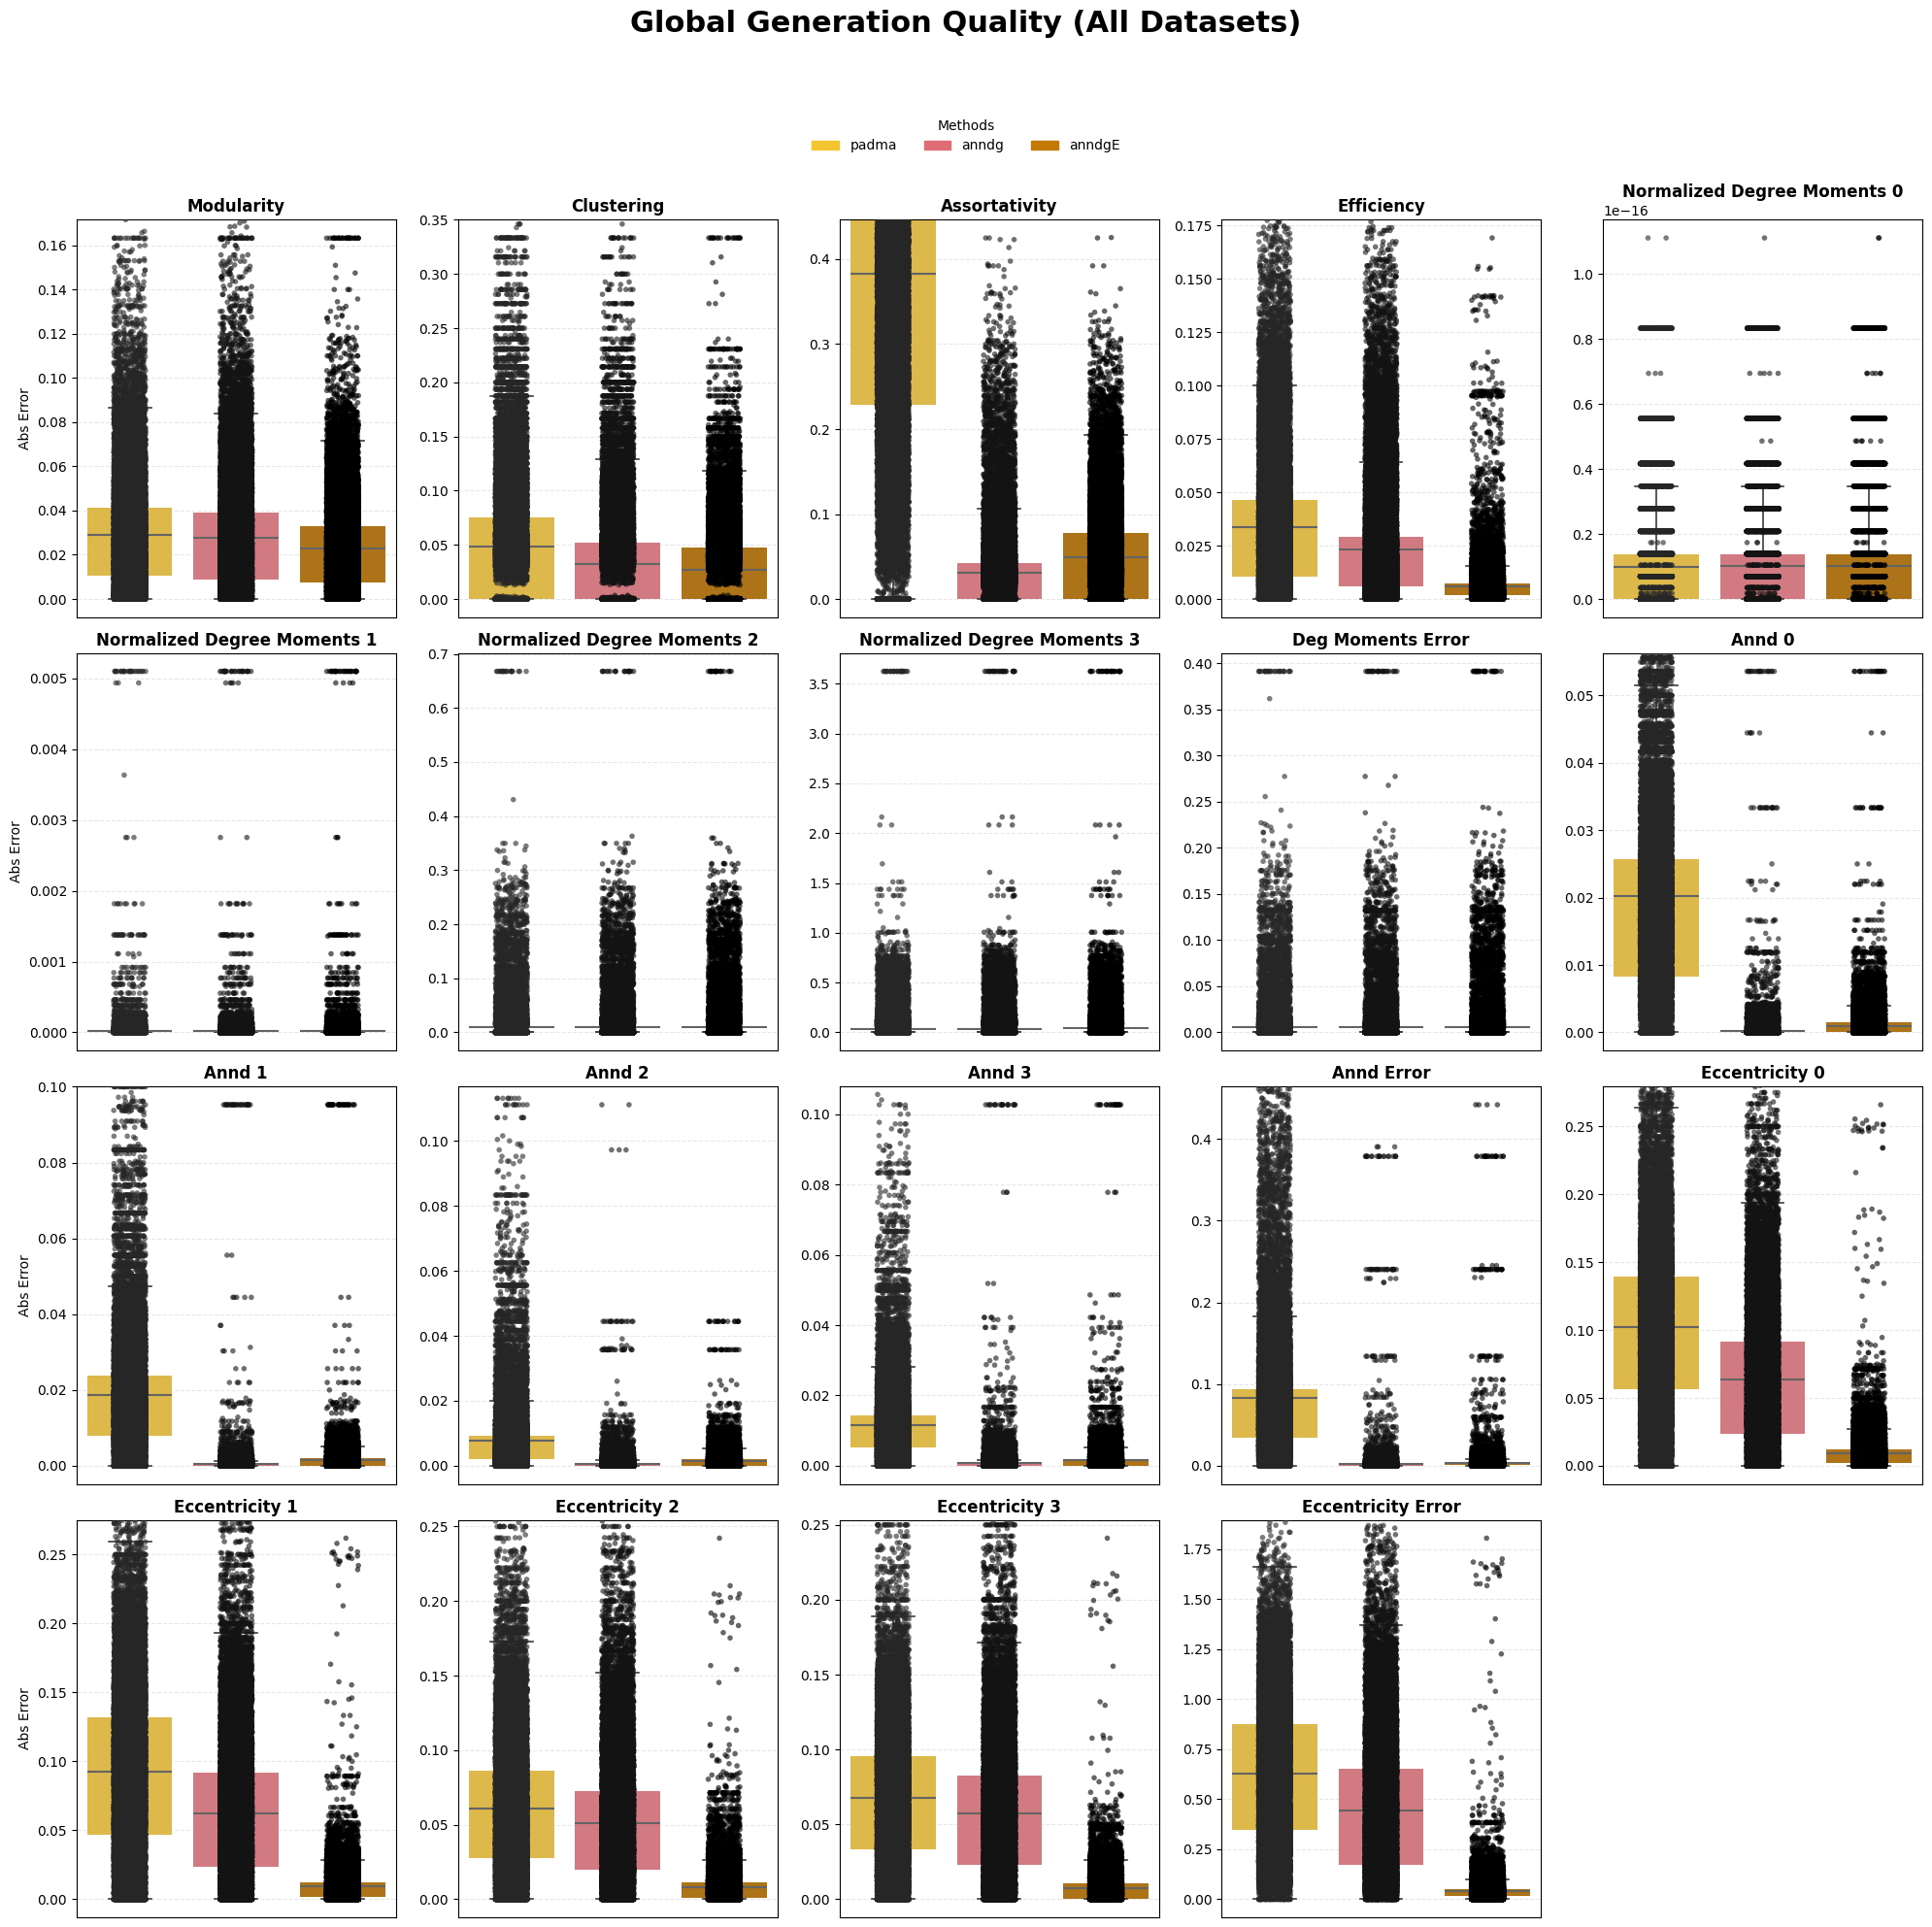


=== Global Replication Score (Lower is better) ===


,Global_Replication_Score
method,
anndgE,0.439851
anndg,0.726511
padma,1.675745


In [5]:
def generate_global_summary(df_errs: pd.DataFrame, metrics: list[str]) -> Tuple[pd.DataFrame, pd.Series]:
    """Generates a summary of errors per dataset/method and computes a global replication score."""
    valid_metrics = [m for m in metrics if m in df_errs.columns]
    
    # 1. Plotting global distributions (aggregated across all datasets)
    melted_df = df_errs.melt(
        id_vars=["dataset", "method", "graph_idx", "variant_idx"],
        value_vars=valid_metrics,
        var_name="stat",
        value_name="error"
    )
    
    n_stats = len(valid_metrics)
    max_cols = 5
    n_cols = min(n_stats, max_cols)
    n_rows = (n_stats + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), squeeze=False)
    axes_flat = axes.flatten()
    
    for i, stat in enumerate(valid_metrics):
        ax = axes_flat[i]
        df_stat = melted_df[melted_df["stat"] == stat].dropna(subset=["error"])
        if df_stat.empty: continue

        present_methods = [m for m in METHODS if m in df_stat["method"].unique()]
        plot_performance_distribution(
            ax=ax, df=df_stat, x="method", y="error", hue="method",
            palette=PALETTE, order=present_methods, hue_order=present_methods
        )
        
        # Set dynamic Y limits based on tightest method
        method_stats = {}
        for m in present_methods:
            m_errors = df_stat[df_stat["method"] == m]["error"].dropna().values
            if len(m_errors) > 0:
                method_stats[m] = {"max": np.percentile(m_errors, 100), "data": m_errors}
        
        if method_stats:
            tightest_m = min(method_stats.keys(), key=lambda k: method_stats[k]["max"])
            set_dynamic_ylim(ax, method_stats[tightest_m]["data"], percentile=100, expansion=1.1)
        
        ax.set_title(stat.replace("_", " ").title(), fontsize=12, fontweight='bold')
        ax.set_ylabel("Abs Error" if i % n_cols == 0 else "")
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    for j in range(i + 1, n_rows * n_cols): fig.delaxes(axes_flat[j])

    available_methods = [m for m in METHODS if m in df_errs["method"].unique()]
    legend_patches = [mpatches.Patch(color=PALETTE[m], label=m) for m in available_methods]
    fig.legend(handles=legend_patches, title="Methods", loc='upper center', 
               bbox_to_anchor=(0.5, 0.94), ncol=len(available_methods), frameon=False)
    plt.suptitle("Global Generation Quality (All Datasets)", fontsize=22, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # 2. Global Replication Score
    # Mean error of each method per metric (averaged over all datasets and graphs)
    method_mean_errors = df_errs.groupby('method', observed=True)[valid_metrics].mean()
    
    # Mean error across all methods for each metric
    metric_means_across_methods = method_mean_errors.mean()
    
    # Normalize: E_{m,k} / mu_k
    # We add a small epsilon to avoid division by zero
    normalized_errors = method_mean_errors / (metric_means_across_methods + 1e-12)
    
    # Final score: mean of normalized errors across all metrics
    global_scores = normalized_errors.mean(axis=1).rename("Global_Replication_Score").sort_values()
    
    print("\n=== Global Replication Score (Lower is better) ===")
    display(global_scores.to_frame())
    
    return global_scores

global_scores = generate_global_summary(df_errors, plot_stats)